<a href="https://colab.research.google.com/github/nithisharul/Nithish-Arul---Kmeans-algorithm-ACM-Technical-Domain-Task-Submission/blob/main/K_means_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

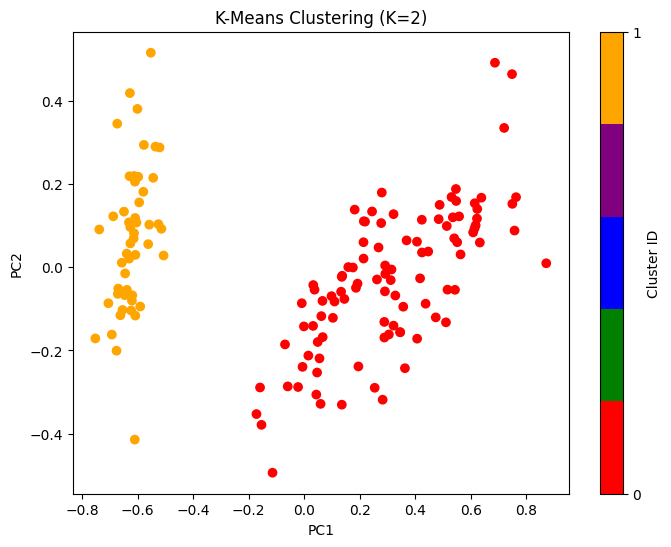

Inertia: 12.1278
Silhouette Score: 0.6300


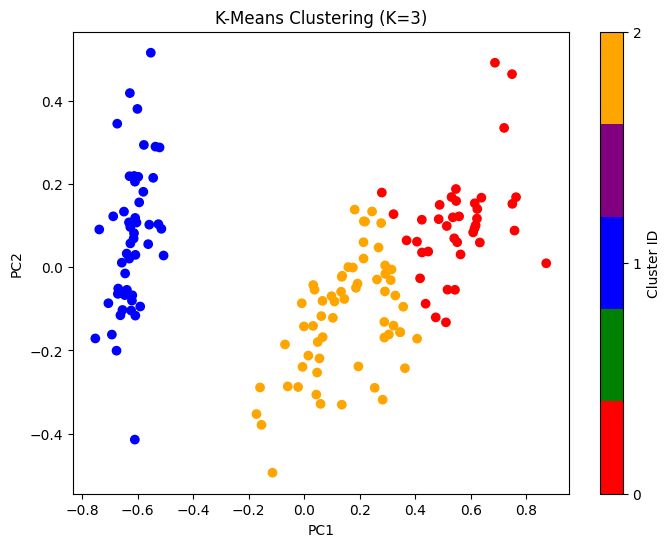

Inertia: 6.9822
Silhouette Score: 0.5048


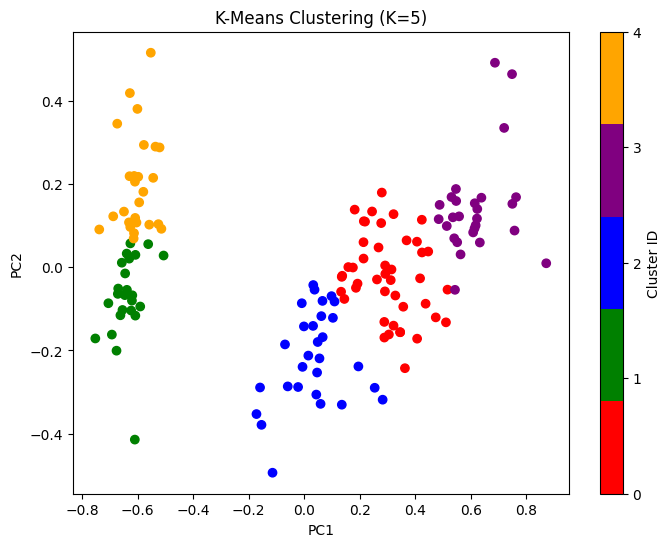

Inertia: 4.5889
Silhouette Score: 0.3486


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from matplotlib.colors import ListedColormap


iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Normalize data to reduce bias while forming clusters
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(iris_df)

cstm_cmap = ListedColormap(['red', 'green', 'blue', 'purple', 'orange'])

# Function to apply K-Means algorithm and plot the clusters
def apply_kmeans_and_plot(k):
    kmeans = KMeans(n_clusters=k, random_state=10, n_init=10)
    labels = kmeans.fit_predict(normalized_data)

    # we use pca as a dimensional reduction technique to reduce 4d data to 2d data
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(normalized_data)


    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap=cstm_cmap)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'K-Means Clustering (K={k})')


    colorbar = plt.colorbar(scatter, ticks=np.arange(k))
    colorbar.set_label("Cluster ID")

    plt.show()

    # Computing and printing evaluation metrics
    inertia = kmeans.inertia_ #Tells how compact clusters are , the lower the intertia score the better.
    sil_score = silhouette_score(normalized_data, labels) #Measures similarity of a point to points in its own clusters as comp to other cluster , higher the silhouette score the better.
    db_score = davies_bouldin_score(normalized_data, labels) #Indicates intra cluster dist and inter cluster seperation , lower the score the better.
    ch_score = calinski_harabasz_score(normalized_data, labels) #indicates how well defined the clusters are , higher the score the better.

    print(f"Inertia: {inertia:.4f}")
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin Score: {db_score:.4f}")
    print(f"Calinski-Harabasz Score: {ch_score:.4f}")
    return kmeans

# Apply K-Means for K = 2, 3, and 5.we chose k=2 to show underfitting(k=2) and k=5 to show overfitting(k=5)
kmeans_2 = apply_kmeans_and_plot(2)
kmeans_3 = apply_kmeans_and_plot(3)
kmeans_5 = apply_kmeans_and_plot(5)

# Function to predict new data points and add them to existing clusters
def predict_cluster(kmeans_model, new_points):
    new_points_scaled = scaler.transform(new_points)  # Normalize new data
    predicted_labels = kmeans_model.predict(new_points_scaled)  # Predict cluster
    return predicted_labels

